# Lesson 10 — Sampling distributions & the Central Limit Theorem

*Part 1 · Lesson 10 of 20  ·  data: Lending Club · simulation*

**←** [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 11: Estimation & standard error](11-estimation.ipynb) **→**

**Same idea, another way:**  [Another dataset →](10-sampling-distributions-clt~another-dataset.ipynb)  ·  [The code behind it →](10-sampling-distributions-clt~the-code.ipynb)

This is the **engine room** of the whole course. We'll take a population that is *wildly* lopsided — real personal incomes — and watch something almost magical happen: when you take the **average of a sample**, those averages pile up into a tidy **bell curve**, even though the raw data looks nothing like one. That single fact — the **Central Limit Theorem** — is what makes confidence intervals and most of statistics possible.

Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()
rng = np.random.default_rng(12)  # fixed seed -> reproducible; learner can change it

LOANS_URL = 'https://www.openintro.org/data/csv/loans_full_schema.csv'
loans = sl.load_csv('loans.csv', url=LOANS_URL)

# Our "population": 10,000 borrowers' self-reported annual incomes.
population = loans['annual_income'].dropna().to_numpy()
MU    = population.mean()           # the TRUE population mean
SIGMA = population.std(ddof=0)      # the TRUE population standard deviation
N_POP = len(population)
print(f'Population: {N_POP:,} borrowers')
print(f'TRUE mean   MU    = ${MU:,.0f}')
print(f'TRUE stdev  SIGMA = ${SIGMA:,.0f}')
print(f'Skewness         = {stats.skew(population):.2f}   (0 = symmetric; this is HUGELY right-skewed)')

Population: 10,000 borrowers
TRUE mean   MU    = $79,222
TRUE stdev  SIGMA = $64,731
Skewness         = 9.03   (0 = symmetric; this is HUGELY right-skewed)


## 1) The population — a shape that is *not* a bell curve

Before we average anything, look at the raw data. These are annual incomes, and like most income data they are violently **right-skewed**: a huge crowd of ordinary incomes, then a long thin tail of a few very high earners stretching to the right.

- **The math:** the *skewness* statistic measures lopsidedness. A symmetric bell curve has skewness $0$. This population's skewness is about $9$ — extreme.
- **The meaning:** the average ($\mu$) sits well to the *right* of the typical (median) borrower, dragged up by the millionaires in the tail.
- **The interpretation:** this is exactly the kind of ugly, real-world distribution where you might *expect* statistics to break. Hold that thought.

*(The few incomes above 300,000 dollars are squished into one tall "everything bigger" bar at the right edge so the rest is readable — the tail actually runs all the way to 2.3 million.)*

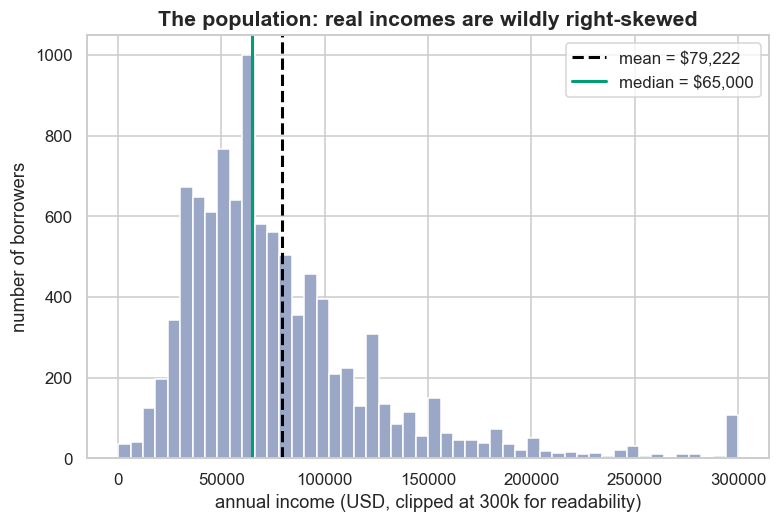

Notice: the mean sits to the RIGHT of the median - the long tail pulls it up.


In [2]:
CLIP = 300_000        # x-axis cutoff just for readability (try raising it)
clipped = np.clip(population, None, CLIP)

fig, ax = plt.subplots()
ax.hist(clipped, bins=50, color='#9aa7c7', edgecolor='white')
ax.axvline(MU, color='black', lw=2, ls='--', label=f'mean = ${MU:,.0f}')
ax.axvline(np.median(population), color='#009E73', lw=2,
           label=f'median = ${np.median(population):,.0f}')
ax.set_xlabel('annual income (USD, clipped at 300k for readability)')
ax.set_ylabel('number of borrowers')
ax.set_title('The population: real incomes are wildly right-skewed')
ax.legend(); plt.show()
print('Notice: the mean sits to the RIGHT of the median - the long tail pulls it up.')

## 2) One sample — the sample mean is itself just *one* random number

In real life you can't survey everyone. You take a **sample**. Here we draw $n=30$ borrowers at random and compute their average income, $\bar{x}$ ("x-bar").

- **The math:** $\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — add up the 30 incomes, divide by 30.
- **The meaning:** $\bar{x}$ is our *estimate* of the unknown population mean $\mu$.
- **The interpretation:** this single number is a **roll of the dice**. Draw a different 30 people and you'd get a different $\bar{x}$. So $\bar{x}$ is not a fixed fact — it is a **random variable** with a distribution of its own. That distribution is the whole point of this lesson.

**Try it:** the next cell draws *two* different samples so you can see two different averages — and if you press **Shift + Enter** on it a few times, the number keeps landing somewhere new. That jiggle is exactly what we're about to map.

In [3]:
n = 30
one_sample = rng.choice(population, size=n, replace=True)
xbar = one_sample.mean()
print(f'This sample of {n} borrowers had mean income  xbar = ${xbar:,.0f}')
print(f'The true population mean is                    MU   = ${MU:,.0f}')
print()
print()
xbar2 = rng.choice(population, size=n, replace=True).mean()
print(f'A second random sample of {n} gave           xbar = ${xbar2:,.0f}')
print('Different sample -> different mean. xbar wobbles. That wobble has a shape.')

This sample of 30 borrowers had mean income  xbar = $78,150
The true population mean is                    MU   = $79,222


A second random sample of 30 gave           xbar = $80,737
Different sample -> different mean. xbar wobbles. That wobble has a shape.


## 3) Many samples — the *sampling distribution* of the mean

So let's stop looking at one $\bar{x}$ and look at *thousands* of them. We'll repeat "draw 30 people, record their average" **5,000 times** and histogram the 5,000 averages. That histogram is the **sampling distribution of the mean**. *(It's drawn on a **density** scale — area sums to 1 — so we can lay the predicted bell curve right on top; don't worry about the exact y-axis numbers, only the shape.)*

Watch what happens to the shape.

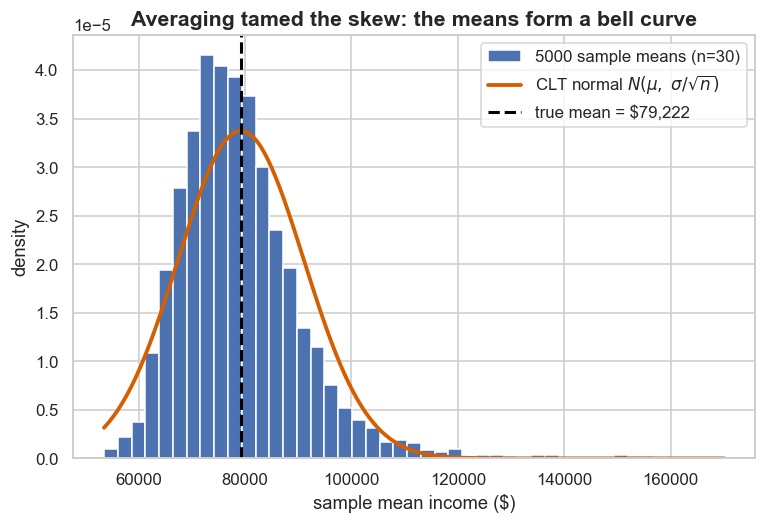

Skew of the raw population:   9.03   (extreme)
Skew of the 5,000 means:      1.72   (down from ~9 -> much closer to symmetric; some right-skew still lingers)
Center of the means:        $79,232   (vs true MU = $79,222)


In [4]:
n = 30
n_reps = 5000
sample_means = np.array([rng.choice(population, size=n, replace=True).mean()
                         for _ in range(n_reps)])

fig, ax = plt.subplots()
ax.hist(sample_means, bins=45, density=True, color='#4c72b0', edgecolor='white',
        label=f'{n_reps} sample means (n={n})')
# Overlay the Central Limit Theorem's prediction: a normal bell curve.
xs = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA / np.sqrt(n)),
        color='#D55E00', lw=2.5, label=r'CLT normal $N(\mu,\ \sigma/\sqrt{n})$')
ax.axvline(MU, color='black', lw=2, ls='--', label=f'true mean = ${MU:,.0f}')
ax.set_xlabel('sample mean income ($)'); ax.set_ylabel('density')
ax.set_title('Averaging tamed the skew: the means form a bell curve')
ax.legend(); plt.show()

print(f'Skew of the raw population:   {stats.skew(population):.2f}   (extreme)')
print(f'Skew of the 5,000 means:      {stats.skew(sample_means):.2f}   (down from ~9 -> much closer to symmetric; some right-skew still lingers)')
print(f'Center of the means:        ${sample_means.mean():,.0f}   (vs true MU = ${MU:,.0f})')

**What just happened?** The raw incomes were savagely skewed (skewness ≈ 9), yet their **averages** are far more symmetric — a rough bell **centered right on the true mean** $\mu$ that already hugs the red curve. (A little right-skew still lingers because $n=30$ is a small sample of an *extremely* lopsided population; Section 4 shows it keeps improving as $n$ grows, and Section 6 shows a cleaner case.) That red curve is the **Central Limit Theorem (CLT)** at work:

$$\bar{x} \;\approx\; N\!\left(\mu,\ \frac{\sigma}{\sqrt{n}}\right)$$

- **The math:** for large enough $n$, the sampling distribution of $\bar{x}$ is approximately **normal**, with mean $\mu$ and standard deviation $\sigma/\sqrt{n}$ — *no matter what shape the population has*.
- **The meaning:** averaging is a **smoothing machine**. One weird income can blow up a single value, but it gets diluted by 29 ordinary ones, so extreme averages are rare.
- **The interpretation:** even from messy real data, we can describe how $\bar{x}$ behaves with a clean, predictable curve. *That* is what lets us put error bars on estimates.

## 4) The effect of $n$ — bigger samples are *more normal* and *narrower*

The CLT is a story about growing $n$. Let's draw the sampling distribution for four sample sizes side by side: $n = 1, 5, 30, 100$.

- $n=1$ is a beautiful anchor: a "sample of 1" is just a single income, so its histogram looks essentially like the raw skewed population again.
- As $n$ climbs, two things happen at once: the shape becomes **more bell-like**, and the spread gets **narrower** (the averages cluster tighter around $\mu$).

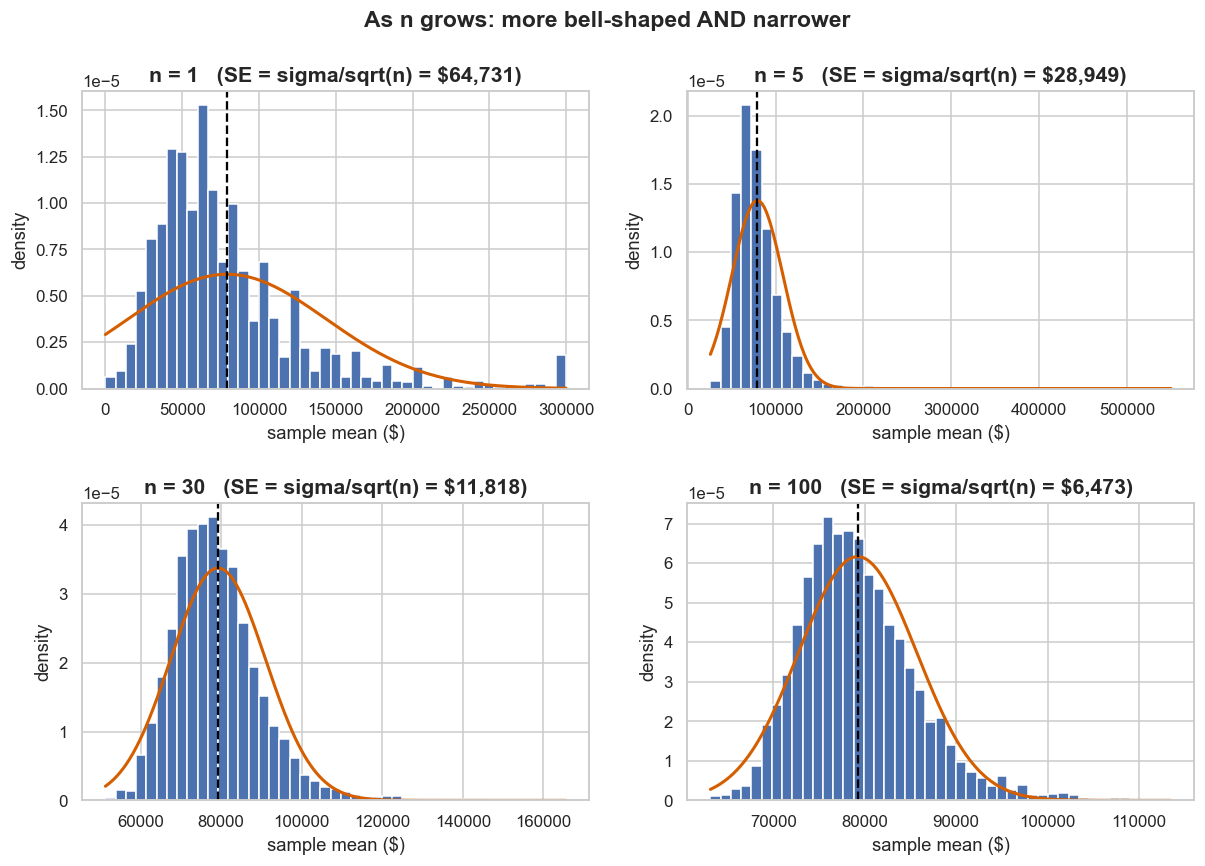

n=1 is just single incomes, so it looks like the raw skewed population again. By n=30 it is bell-like.


In [5]:
sizes = [1, 5, 30, 100]
n_reps = 5000

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, n in zip(axes.ravel(), sizes):
    means = np.array([rng.choice(population, size=n, replace=True).mean()
                      for _ in range(n_reps)])
    # Clip just the display for n=1 so its long tail doesn't squash the others.
    shown = np.clip(means, None, 300_000) if n == 1 else means
    ax.hist(shown, bins=45, density=True, color='#4c72b0', edgecolor='white')
    xs = np.linspace(shown.min(), shown.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA / np.sqrt(n)), color='#D55E00', lw=2)
    ax.axvline(MU, color='black', lw=1.5, ls='--')
    ax.set_title(f'n = {n}   (SE = sigma/sqrt(n) = ${SIGMA/np.sqrt(n):,.0f})')
    ax.set_xlabel('sample mean ($)'); ax.set_ylabel('density')
fig.suptitle('As n grows: more bell-shaped AND narrower', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print('n=1 is just single incomes, so it looks like the raw skewed population again. By n=30 it is bell-like.')

## 5) The standard error and the $\sqrt{n}$ law

How wide is that bell? Its standard deviation has a special name — the **standard error (SE)** — and a beautifully simple formula:

$$\text{SE} \;=\; \frac{\sigma}{\sqrt{n}}$$

- **The math:** divide the population's standard deviation $\sigma$ by the square root of the sample size.
- **The meaning:** the SE is the typical "give or take" of a single sample mean — how far $\bar{x}$ usually lands from the true $\mu$.
- **The interpretation:** precision improves only with the **square root** of $n$. Because of that $\sqrt{n}$, to **halve** your error you must **quadruple** your sample. Effort buys precision, but at a diminishing rate.

First, let's confirm the formula against our simulation.

In [6]:
n = 30
sample_means = np.array([rng.choice(population, size=n, replace=True).mean()
                         for _ in range(5000)])
empirical_se = sample_means.std()
theory_se    = SIGMA / np.sqrt(n)
print(f'Std of the 5,000 sample means (measured) = ${empirical_se:,.0f}')
print(f'CLT prediction  sigma/sqrt(n)            = ${theory_se:,.0f}')
print('They match -> the SE formula really describes the wobble of xbar.')

Std of the 5,000 sample means (measured) = $11,977
CLT prediction  sigma/sqrt(n)            = $11,818
They match -> the SE formula really describes the wobble of xbar.


In [7]:
# The sqrt(n) law: quadruple n, and SE should roughly HALVE.
def measured_se(n, reps=4000):
    m = np.array([rng.choice(population, size=n, replace=True).mean() for _ in range(reps)])
    return m.std()

for n_small, n_big in [(25, 100), (100, 400)]:
    se_small = measured_se(n_small)
    se_big   = measured_se(n_big)
    print(f'n={n_small:>3}: SE = ${se_small:>8,.0f}   ->   n={n_big:>3}: SE = ${se_big:>8,.0f}'
          f'   (ratio {se_small/se_big:.2f}, theory = 2.00)')
print()
print('Quadrupling n cuts the standard error about in half. That is the sqrt(n) law.')

n= 25: SE = $  13,413   ->   n=100: SE = $   6,388   (ratio 2.10, theory = 2.00)


n=100: SE = $   6,395   ->   n=400: SE = $   3,190   (ratio 2.00, theory = 2.00)

Quadrupling n cuts the standard error about in half. That is the sqrt(n) law.


## 6) "Any shape works" — the CLT is not about the data being normal

A common myth is that the CLT needs the data to already look bell-shaped. It does **not**. The whole point is that the *averaging* creates the bell, regardless of the starting shape.

To prove it, we'll abandon the income data and invent a brand-new, **simulated** population with a totally different shape — a lumpy **bimodal mixture** (two separated humps, like a crowd of two distinct groups). Nothing bell-shaped about it. Then we average.

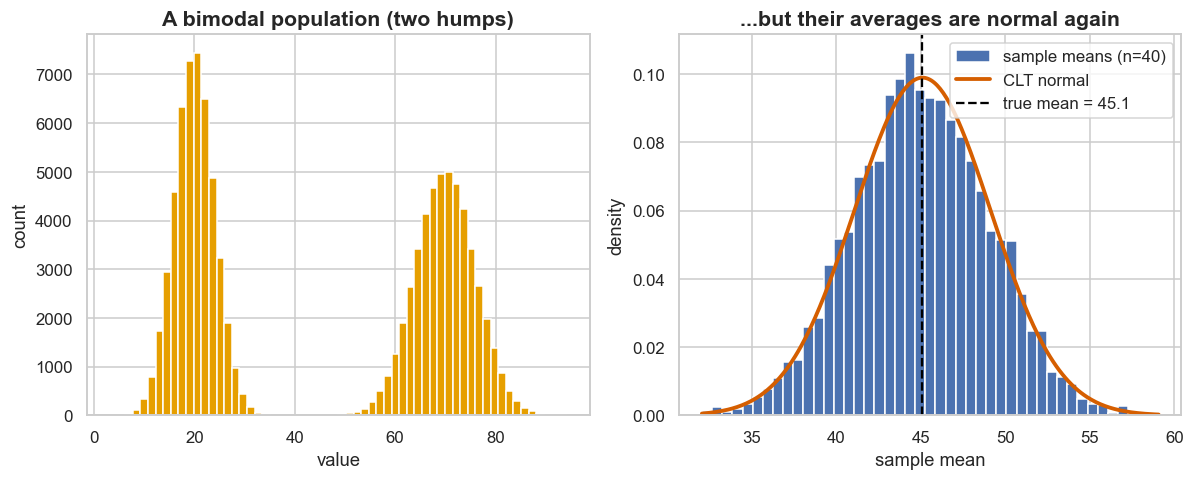

Skew of this population: 0.04   Skew of its means:       0.01
Two humps in -> one clean bell out. The CLT does not care about the input shape.


In [8]:
# A made-up population with TWO humps - deliberately un-bell-like.
pop_size = 100_000
group = rng.random(pop_size) < 0.5
weird_pop = np.where(group,
                     rng.normal(20, 4, pop_size),    # hump 1
                     rng.normal(70, 6, pop_size))    # hump 2
mu_w    = weird_pop.mean()
sigma_w = weird_pop.std(ddof=0)

n = 40
weird_means = np.array([rng.choice(weird_pop, size=n, replace=True).mean()
                        for _ in range(5000)])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
a1.hist(weird_pop, bins=60, color='#E69F00', edgecolor='white')
a1.set_title('A bimodal population (two humps)')
a1.set_xlabel('value'); a1.set_ylabel('count')

a2.hist(weird_means, bins=45, density=True, color='#4c72b0', edgecolor='white',
        label=f'sample means (n={n})')
xs = np.linspace(weird_means.min(), weird_means.max(), 300)
a2.plot(xs, stats.norm.pdf(xs, mu_w, sigma_w/np.sqrt(n)), color='#D55E00', lw=2.5,
        label='CLT normal')
a2.axvline(mu_w, color='black', ls='--', lw=1.5, label=f'true mean = {mu_w:.1f}')
a2.set_title('...but their averages are normal again')
a2.set_xlabel('sample mean'); a2.set_ylabel('density'); a2.legend()
plt.tight_layout(); plt.show()
print(f'Skew of this population: {stats.skew(weird_pop):.2f}   '
      f'Skew of its means:       {stats.skew(weird_means):.2f}')
print('Two humps in -> one clean bell out. The CLT does not care about the input shape.')

## 7) The bridge — why this powers confidence intervals

Here is the payoff that the rest of the course rests on. We now know that a sample mean behaves like:

$$\bar{x} \;\approx\; N\!\left(\mu,\ \frac{\sigma}{\sqrt{n}}\right)$$

Because that distribution is **normal**, we can borrow the bell curve's famous **68–95–99.7 rule**: about **95%** of sample means land within roughly **2 standard errors** of the true mean $\mu$. Turn that around — for about 95% of samples, the true $\mu$ lies within $\pm 2\,\text{SE}$ of the $\bar{x}$ you observed. That window,

$$\bar{x} \;\pm\; (\text{about } 2)\cdot \frac{\sigma}{\sqrt{n}},$$

is a **95% confidence interval**.

- **The meaning:** the standard error is the natural "ruler" for how far our estimate might be off.
- **The interpretation:** we can quote an estimate *with honest error bars* even though we only ever saw one sample — because the CLT tells us how that one sample's mean behaves.

Let's see this "about 95% land within 2 SE" promise directly in our income simulation.

In [9]:
n = 30
sample_means = np.array([rng.choice(population, size=n, replace=True).mean()
                         for _ in range(5000)])
SE = SIGMA / np.sqrt(n)
within2 = np.mean(np.abs(sample_means - MU) <= 2 * SE) * 100
print(f'Sample means landing within 2 SE of the true mean: {within2:.1f}%')
print(f'The 68-95-99.7 rule predicts about 95%.')
print()
print('That 95% is the seed of the confidence interval - the flagship demo grows it')
print('into 100 real intervals and counts how many catch the true mean.')

Sample means landing within 2 SE of the true mean: 96.0%
The 68-95-99.7 rule predicts about 95%.

That 95% is the seed of the confidence interval - the flagship demo grows it
into 100 real intervals and counts how many catch the true mean.


## Now you try

Predict what will happen, then change one thing and re-run:

1. **Shrink the sample.** Scroll up to the first code cell under heading **3**, find the line that reads `n = 30`, change the `30` to `5`, and press **Shift + Enter** on that cell. Does the bell get *fatter* or *thinner*? Is it still symmetric, or does a little skew creep back in?
2. **Tame an even uglier variable.** The CLT works on any column. Try `population = loans['loan_amount'].dropna().to_numpy()` in the setup cell (then re-run setup and section 3). Does averaging still produce a bell?
3. **Test the $\sqrt{n}$ law yourself.** In section 5, change the pairs to `[(20, 80), (50, 200)]` (each a 4× jump). Predict the SE ratio *before* running — it should be near 2.00 every time.

## What you learned

- A statistic like the sample mean $\bar{x}$ is itself **random**; the distribution of its possible values is the **sampling distribution**.
- The **Central Limit Theorem**: for large enough $n$, $\bar{x} \approx N(\mu,\ \sigma/\sqrt{n})$ — a **bell curve centered on the true mean** — *even when the population is wildly skewed or bimodal*. Averaging smooths chaos into a bell.
- The **standard error** $\text{SE} = \sigma/\sqrt{n}$ is the spread of that bell — the typical "give or take" of one estimate. The $\sqrt{n}$ law means **quadrupling $n$ only halves the error**.
- Bigger samples make the sampling distribution **both more normal and narrower**.
- Because $\bar{x}$ is approximately normal, about **95% of sample means fall within ~2 SE of $\mu$** — the foundation of the **confidence interval**, which you'll build next.

---

**← Previous:** [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 11: Estimation & standard error](11-estimation.ipynb)

**Same idea, another way:**  [Another dataset →](10-sampling-distributions-clt~another-dataset.ipynb)  ·  [The code behind it →](10-sampling-distributions-clt~the-code.ipynb)